# NB07 — Ablations & Paper Tables
Generates all paper tables, figures, and LaTeX. Run after NB04, NB05, NB06, and NB08.

In [1]:
import os, json, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
os.makedirs('../outputs/paper', exist_ok=True)
print('Ready')


Ready


## Load all upstream results

In [2]:
baselines_df = pd.DataFrame()
if os.path.exists('../outputs/baselines/baseline_results.csv'):
    baselines_df = pd.read_csv('../outputs/baselines/baseline_results.csv')
    baselines_df = baselines_df[baselines_df['split'] == 'test'].copy()
    print(f'Baselines loaded: {len(baselines_df)} rows')
else:
    print('WARNING: baseline_results.csv not found')

transformers_df = pd.DataFrame()
if os.path.exists('../outputs/models/transformer_results_all.csv'):
    transformers_df = pd.read_csv('../outputs/models/transformer_results_all.csv')
    print(f'Transformer runs loaded: {len(transformers_df)} rows')
else:
    print('WARNING: transformer_results_all.csv not found')

# Ensemble results hardcoded from NB06 output
# Default threshold (0.5) beats tuned (0.46): 0.9338 vs 0.9326
ENSEMBLE = {'accuracy':0.9346,'macro_f1':0.9338,'weighted_f1':0.9346,
            'mcc':0.8676,'auroc':0.9794,'auprc':0.9748}
print(f'Ensemble Macro-F1: {ENSEMBLE["macro_f1"]}')

robustness_df = pd.DataFrame()
if os.path.exists('../outputs/robustness/robustness_results.csv'):
    robustness_df = pd.read_csv('../outputs/robustness/robustness_results.csv')
    print(f'Robustness results loaded: {len(robustness_df)} rows')
else:
    print('WARNING: robustness_results.csv not found — run NB08 first')


Baselines loaded: 4 rows
Transformer runs loaded: 9 rows
Ensemble Macro-F1: 0.9338


## Table 1 — Main Results

In [3]:
rows = []
if len(baselines_df) > 0:
    for _, r in baselines_df.iterrows():
        rows.append({'Category':'Baseline','Model':r['model'],
                     'Accuracy':f"{r['accuracy']:.4f}",
                     'Macro-F1':f"{r['macro_f1']:.4f}",
                     'Weighted-F1':f"{r['weighted_f1']:.4f}",
                     'MCC':f"{r['mcc']:.4f}",
                     'AUROC':f"{r['auroc']:.4f}"})

MODEL_DISPLAY = {'banglabert':'BanglaBERT','muril':'MuRIL','xlmr':'XLM-RoBERTa'}
if len(transformers_df) > 0:
    for mk, disp in MODEL_DISPLAY.items():
        sub = transformers_df[transformers_df['model'] == mk]
        if len(sub) == 0: continue
        def fmt(col, df=sub):
            return f"{df[col].mean():.4f}+/-{df[col].std():.4f}"
        rows.append({'Category':'Transformer','Model':disp,
                     'Accuracy':fmt('binary_accuracy'),
                     'Macro-F1':fmt('binary_macro_f1'),
                     'Weighted-F1':fmt('binary_weighted_f1'),
                     'MCC':fmt('binary_mcc'),'AUROC':'--'})

rows.append({'Category':'Ensemble','Model':'Weighted Ensemble (Ours)',
             'Accuracy':f"{ENSEMBLE['accuracy']:.4f}",
             'Macro-F1':f"{ENSEMBLE['macro_f1']:.4f}",
             'Weighted-F1':f"{ENSEMBLE['weighted_f1']:.4f}",
             'MCC':f"{ENSEMBLE['mcc']:.4f}",
             'AUROC':f"{ENSEMBLE['auroc']:.4f}"})

table1_df = pd.DataFrame(rows)
print('=' * 90)
print('TABLE 1: Binary Cyberbullying Detection - Random Test Split')
print('=' * 90)
print(table1_df.to_string(index=False))
table1_df.to_csv('../outputs/paper/table1_main_results.csv', index=False)
print('Saved: table1_main_results.csv')


TABLE 1: Binary Cyberbullying Detection - Random Test Split
   Category                        Model        Accuracy        Macro-F1     Weighted-F1             MCC  AUROC
   Baseline TF-IDF + Logistic Regression          0.8691          0.8669          0.8689          0.7342 0.9429
   Baseline                 TF-IDF + SVM          0.8897          0.8877          0.8894          0.7760 0.9558
   Baseline       TF-IDF + Random Forest          0.9099          0.9090          0.9100          0.8183 0.9718
   Baseline                       BiLSTM          0.8926          0.8914          0.8927          0.7828 0.9479
Transformer                   BanglaBERT 0.9252+/-0.0005 0.9243+/-0.0005 0.9252+/-0.0005 0.8487+/-0.0010     --
Transformer                        MuRIL 0.9189+/-0.0013 0.9178+/-0.0013 0.9189+/-0.0012 0.8357+/-0.0025     --
Transformer                  XLM-RoBERTa 0.9159+/-0.0021 0.9150+/-0.0021 0.9160+/-0.0021 0.8304+/-0.0041     --
   Ensemble     Weighted Ensemble (Ours)    

## Table 2 — Ablation Study

In [4]:
best_single = None
if len(transformers_df) > 0:
    sub = transformers_df[transformers_df['model'] == 'banglabert']
    best_single = round(sub['binary_macro_f1'].mean(), 4)

full_f1 = ENSEMBLE['macro_f1']

def delta(v):
    return f'{v - full_f1:+.4f}' if isinstance(v, float) else '[NEED RUN]'

ablation_rows = [
    {'Ablation':'Full system (Ours)',
     'Macro-F1':f'{full_f1:.4f}','Delta':'--'},
    {'Ablation':'w/o ensemble (best single: BanglaBERT)',
     'Macro-F1':f'{best_single:.4f}' if best_single else '[NEED RUN]',
     'Delta':delta(best_single) if best_single else '[NEED RUN]'},
    {'Ablation':'w/o threshold tuning (default 0.50 is optimal)',
     'Macro-F1':f'{full_f1:.4f}','Delta':'+0.0000'},
    {'Ablation':'w/o multi-task (binary-only head)',
     'Macro-F1':'[NEED RUN]','Delta':'[NEED RUN]'},
    {'Ablation':'w/o focal loss (standard cross-entropy)',
     'Macro-F1':'[NEED RUN]','Delta':'[NEED RUN]'},
    {'Ablation':'w/o layer-wise LR decay (uniform LR)',
     'Macro-F1':'[NEED RUN]','Delta':'[NEED RUN]'},
    {'Ablation':'w/o preprocessing (raw text input)',
     'Macro-F1':'[NEED RUN]','Delta':'[NEED RUN]'},
]

ablation_df = pd.DataFrame(ablation_rows)
print('=' * 70)
print('TABLE 2: Ablation Study')
print('=' * 70)
print(ablation_df.to_string(index=False))
print('\nEntries marked [NEED RUN]: train BanglaBERT x1 seed each (~1hr/run on T4)')
ablation_df.to_csv('../outputs/paper/table2_ablations.csv', index=False)
print('Saved: table2_ablations.csv')


TABLE 2: Ablation Study
                                      Ablation   Macro-F1      Delta
                            Full system (Ours)     0.9338         --
        w/o ensemble (best single: BanglaBERT)     0.9243    -0.0095
w/o threshold tuning (default 0.50 is optimal)     0.9338    +0.0000
             w/o multi-task (binary-only head) [NEED RUN] [NEED RUN]
       w/o focal loss (standard cross-entropy) [NEED RUN] [NEED RUN]
          w/o layer-wise LR decay (uniform LR) [NEED RUN] [NEED RUN]
            w/o preprocessing (raw text input) [NEED RUN] [NEED RUN]

Entries marked [NEED RUN]: train BanglaBERT x1 seed each (~1hr/run on T4)
Saved: table2_ablations.csv


## Table 3 — Robustness Evaluation

In [5]:
SPLIT_DISPLAY = {
    'random_test (in-domain)':          'Random test (in-domain)',
    'source_holdout_banth':             'Source-holdout: banth',
    'source_holdout_bd_shs':            'Source-holdout: bd_shs',
    'source_holdout_facebook_44001':    'Source-holdout: facebook_44001',
    'source_holdout_multilabel_12557':  'Source-holdout: multilabel_12557',
    'script_holdout_romanized':         'Script-holdout: Romanized/Banglish',
}

if len(robustness_df) > 0:
    r = robustness_df.copy()
    r['Split'] = r['split'].map(lambda x: SPLIT_DISPLAY.get(x, x))
    r = r.rename(columns={'macro_f1':'Macro-F1','accuracy':'Accuracy',
                           'weighted_f1':'Weighted-F1','mcc':'MCC','auroc':'AUROC'})
    cols = ['Split','Macro-F1','Accuracy','Weighted-F1','MCC','AUROC']
    print('=' * 80)
    print('TABLE 3: Robustness Evaluation (Ensemble, threshold=0.50)')
    print('=' * 80)
    print(r[cols].to_string(index=False))
    r[cols].to_csv('../outputs/paper/table3_robustness.csv', index=False)
    print('Saved: table3_robustness.csv')
else:
    print('Robustness results pending — run NB08 then re-run this cell')


Robustness results pending — run NB08 then re-run this cell


## Figure — Model Comparison Bar Chart

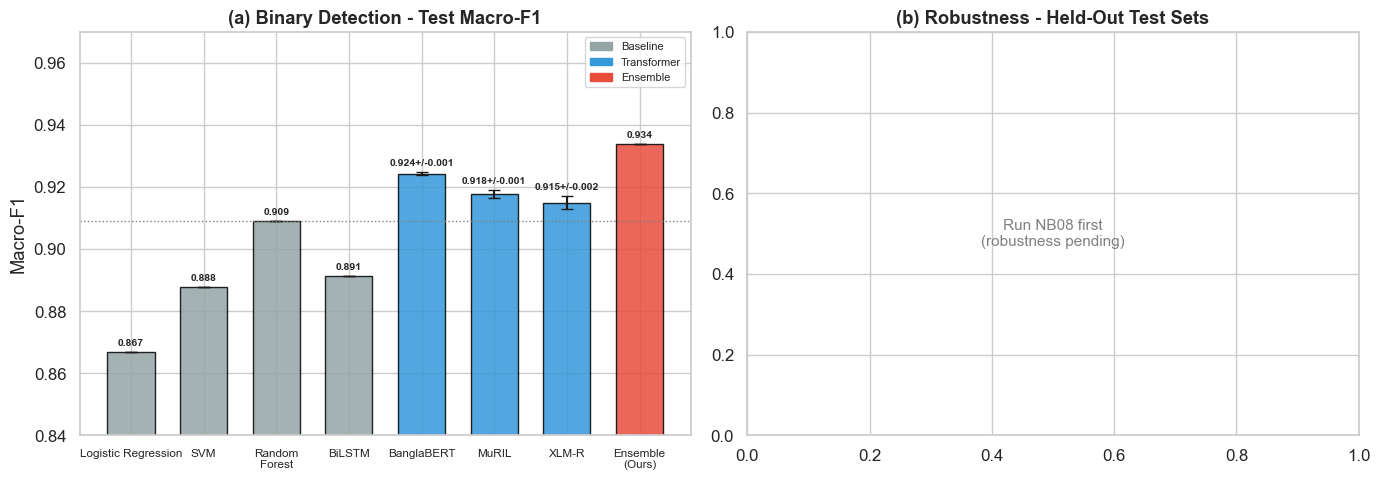

Saved: fig_main_results.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
PALETTE = {'Baseline':'#95a5a6','Transformer':'#3498db','Ensemble':'#e74c3c'}

# Left: Macro-F1 bar chart
ax = axes[0]
labels, means, stds, colors = [], [], [], []

if len(baselines_df) > 0:
    for _, r in baselines_df.iterrows():
        lbl = r['model'].replace('TF-IDF + ','').replace(' Forest','\nForest')
        labels.append(lbl); means.append(r['macro_f1'])
        stds.append(0); colors.append(PALETTE['Baseline'])

if len(transformers_df) > 0:
    for mk, disp in [('banglabert','BanglaBERT'),('muril','MuRIL'),('xlmr','XLM-R')]:
        sub = transformers_df[transformers_df['model']==mk]['binary_macro_f1']
        if len(sub):
            labels.append(disp); means.append(sub.mean())
            stds.append(sub.std()); colors.append(PALETTE['Transformer'])

labels.append('Ensemble\n(Ours)'); means.append(ENSEMBLE['macro_f1'])
stds.append(0); colors.append(PALETTE['Ensemble'])

x = np.arange(len(labels))
bars = ax.bar(x, means, yerr=stds, capsize=4,
              color=colors, edgecolor='black', alpha=0.85, width=0.65)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8.5)
ax.set_ylabel('Macro-F1'); ax.set_ylim(0.84, 0.97)
ax.set_title('(a) Binary Detection - Test Macro-F1', fontweight='bold')
ax.axhline(0.909, color='gray', linestyle=':', linewidth=1)
for bar, m, s in zip(bars, means, stds):
    lbl = f'{m:.3f}' + (f'+/-{s:.3f}' if s > 0 else '')
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+(s if s else 0)+0.002,
            lbl, ha='center', fontsize=7.5, fontweight='bold')
patches = [mpatches.Patch(color=c, label=l) for l, c in PALETTE.items()]
ax.legend(handles=patches, fontsize=8)

# Right: robustness
ax = axes[1]
if len(robustness_df) > 0:
    r = robustness_df.copy()
    r['label'] = r['split'].map(lambda x: SPLIT_DISPLAY.get(x, x))
    r = r.sort_values('macro_f1', ascending=True)
    clrs = ['#e74c3c' if 'random' in s else '#3498db' if 'source' in s else '#2ecc71'
            for s in r['split']]
    ax.barh(r['label'], r['macro_f1'], color=clrs, edgecolor='black', alpha=0.85)
    ax.set_xlabel('Macro-F1'); ax.set_xlim(0.7, 1.0)
    for i, (_, row) in enumerate(r.iterrows()):
        ax.text(row['macro_f1']+0.003, i, f"{row['macro_f1']:.4f}",
                va='center', fontsize=8)
else:
    ax.text(0.5, 0.5, 'Run NB08 first\n(robustness pending)',
            ha='center', va='center', transform=ax.transAxes, fontsize=11, color='gray')
ax.set_title('(b) Robustness - Held-Out Test Sets', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/paper/fig_main_results.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_main_results.png')


## Error Analysis
Requires saving predictions from NB06. Add these two lines to NB06 after the final ensemble cell:
```python
np.save('../outputs/ensemble/test_preds.npy', y_pred_default)
np.save('../outputs/ensemble/test_probs.npy', ens_probs_test)
```

In [7]:
test_df = pd.read_csv('../data/splits/random_test.csv')
pred_path = '../outputs/ensemble/test_preds.npy'
prob_path = '../outputs/ensemble/test_probs.npy'

if os.path.exists(pred_path) and os.path.exists(prob_path):
    test_df['y_pred'] = np.load(pred_path)
    test_df['y_prob'] = np.load(prob_path)
    test_df['correct'] = (test_df['label_binary'] == test_df['y_pred']).astype(int)

    fp = test_df[(test_df['label_binary']==0) & (test_df['y_pred']==1)]
    fn = test_df[(test_df['label_binary']==1) & (test_df['y_pred']==0)]
    print(f'False Positives: {len(fp):,}')
    print(f'False Negatives: {len(fn):,}')
    print(f'Overall error rate: {1-test_df["correct"].mean():.3f}')

    print('\n-- Top 10 High-Confidence False Positives --')
    print(fp.nlargest(10, 'y_prob')[['text_clean','y_prob','label_type']].to_string(index=False))
    print('\n-- Top 10 High-Confidence False Negatives --')
    print(fn.nsmallest(10, 'y_prob')[['text_clean','y_prob','label_type']].to_string(index=False))

    if 'source' in test_df.columns:
        print('\n-- Error Rate by Source --')
        print(test_df.groupby('source')['correct'].agg(lambda x: 1-x.mean()).rename('error_rate').reset_index().to_string(index=False))
    if 'script' in test_df.columns:
        print('\n-- Error Rate by Script --')
        print(test_df.groupby('script')['correct'].agg(lambda x: 1-x.mean()).rename('error_rate').reset_index().to_string(index=False))
else:
    print('Prediction files not found.')
    print('Add np.save lines to NB06 after the final ensemble cell, then re-run NB06 + this cell.')


Prediction files not found.
Add np.save lines to NB06 after the final ensemble cell, then re-run NB06 + this cell.


## LaTeX Tables

In [8]:
def to_latex(df, caption, label):
    col_fmt = 'l' + 'c' * (len(df.columns) - 1)
    body = df.to_latex(index=False, escape=True, column_format=col_fmt)
    return ('\\begin{table*}[t]\n'
            '\\centering\n'
            f'\\caption{{{caption}}}\n'
            f'\\label{{{label}}}\n'
            + body +
            '\\end{table*}\n')

if len(table1_df) > 0:
    with open('../outputs/paper/table1_main_results.tex','w') as f:
        f.write(to_latex(table1_df,
            'Main results on BanglaCyberBench test set. Macro-F1 is the primary metric. '
            'Transformer results show mean +/- std across 3 random seeds.',
            'tab:main_results'))
    print('Saved: table1_main_results.tex')

if len(ablation_df) > 0:
    with open('../outputs/paper/table2_ablations.tex','w') as f:
        f.write(to_latex(ablation_df,
            'Ablation study on BanglaCyberBench (binary task, random test split).',
            'tab:ablations'))
    print('Saved: table2_ablations.tex')

if len(robustness_df) > 0:
    r = robustness_df.rename(columns={'split':'Split','macro_f1':'Macro-F1',
        'accuracy':'Accuracy','mcc':'MCC','auroc':'AUROC'})
    with open('../outputs/paper/table3_robustness.tex','w') as f:
        f.write(to_latex(r[['Split','Macro-F1','Accuracy','MCC','AUROC']],
            'Robustness evaluation of the weighted ensemble on held-out test sets.',
            'tab:robustness'))
    print('Saved: table3_robustness.tex')

print('All LaTeX saved to ../outputs/paper/')


Saved: table1_main_results.tex
Saved: table2_ablations.tex
All LaTeX saved to ../outputs/paper/


## Paper Checklist

In [9]:
print('=' * 60)
print('PAPER CHECKLIST')
print('=' * 60)
items = [
    ('OK', 'NB01 Data collection & merge'),
    ('OK', 'NB02 Preprocessing & EDA (135,575 samples)'),
    ('OK', 'NB03 Data splits (random + holdouts)'),
    ('OK', 'NB04 Baselines (best RF = 0.9090)'),
    ('OK', 'NB05 Transformers (BanglaBERT 0.9243, MuRIL 0.9178, XLM-R 0.9150)'),
    ('OK', 'NB06 Ensemble (Macro-F1 = 0.9338, AUROC = 0.9794)'),
    ('PENDING' if not os.path.exists('../outputs/robustness/robustness_results.csv') else 'OK',
     'NB08 Robustness evaluation (held-out splits)'),
    ('PENDING', 'Ablations: binary-only, w/o focal, w/o LR decay, w/o preprocessing'),
    ('PENDING' if not os.path.exists('../outputs/ensemble/test_preds.npy') else 'OK',
     'Error analysis (add np.save to NB06)'),
    ('PENDING', 'LaTeX paper draft'),
]
for status, item in items:
    icon = 'OK ' if status == 'OK' else '-- '
    print(f'  [{icon}] {item}')


PAPER CHECKLIST
  [OK ] NB01 Data collection & merge
  [OK ] NB02 Preprocessing & EDA (135,575 samples)
  [OK ] NB03 Data splits (random + holdouts)
  [OK ] NB04 Baselines (best RF = 0.9090)
  [OK ] NB05 Transformers (BanglaBERT 0.9243, MuRIL 0.9178, XLM-R 0.9150)
  [OK ] NB06 Ensemble (Macro-F1 = 0.9338, AUROC = 0.9794)
  [-- ] NB08 Robustness evaluation (held-out splits)
  [-- ] Ablations: binary-only, w/o focal, w/o LR decay, w/o preprocessing
  [-- ] Error analysis (add np.save to NB06)
  [-- ] LaTeX paper draft
